In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from qseg import *
import cv2
from my_segmentation import *
from sklearn.metrics import accuracy_score, f1_score, jaccard_score, recall_score, precision_score
import time
import copy
import pandas as pd
from itertools import product

In [8]:

img_path = "C:/Users/syj43/q_seg/datasets/road_sample/images/"
label_path = "C:/Users/syj43/q_seg/datasets/road_sample/labels/"
img_files = [f for f in os.listdir(img_path)]
label_files = [f for f in os.listdir(label_path)] # ground truth

images = [cv2.imread(img_path+f, cv2.IMREAD_GRAYSCALE) for f in img_files]
masks = [cv2.imread(label_path+f, cv2.IMREAD_GRAYSCALE) for f in label_files]

In [5]:
# test run
i = 0
sample = images[i]
dim = sample.shape[0]

# image to graph
start = time.time()
G = qseg_graph_construction(sample, normalized=False)

bqm, sampleset = annealer_solver_sa(G)
sampleset_first = sampleset.first.sample
end = time.time()
runtime = round(end - start, 3)

accuracy, iou, precision, recall, f1 = qseg_evaluation(sampleset_first, dim, masks[i])
print(runtime, accuracy, iou, f1, precision, recall)


39.696 0.517 0.176 0.23 0.659 0.511


In [6]:
results = []

for i in range(len(images)):
    sample = images[i]
    dim = sample.shape[0]

    start = time.time()
    # image to graph
    G = qseg_graph_construction(sample, normalized=False)
    end = time.time()
    conversion_time = round(end-start,3)

    start = time.time()
    bqm, sampleset = annealer_solver_sa(G)
    sampleset_first = sampleset.first.sample
    end = time.time()
    annealing_time = round(end-start,3)

    accuracy, iou, precision, recall, f1 = qseg_evaluation(sampleset_first, dim, masks[i])
    
    results.append({
        'Accuracy': accuracy,
        'IoU': iou,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Conversion time': conversion_time,
        'Annealing time' : annealing_time,

    })

df = pd.DataFrame(results)
df

,Accuracy,IoU,Precision,Recall,F1,Conversion time,Annealing time
0,0.826,0.277,0.656,0.618,0.302,1.781,39.522
1,0.509,0.173,0.653,0.510,0.228,1.907,38.619
2,0.718,0.242,0.651,0.585,0.280,1.929,42.571
3,0.909,0.304,0.646,0.657,0.318,1.948,43.389
4,0.730,0.246,0.646,0.592,0.283,1.783,41.971
5,0.768,0.256,0.653,0.598,0.290,2.093,35.017
6,0.807,0.271,0.653,0.614,0.299,2.062,39.727
7,0.483,0.167,0.648,0.506,0.223,1.797,41.535
8,0.623,0.214,0.659,0.551,0.261,2.098,33.558
9,0.553,0.185,0.646,0.525,0.238,2.149,40.633


In [7]:
df.to_csv('road_qseg.csv', index=False)

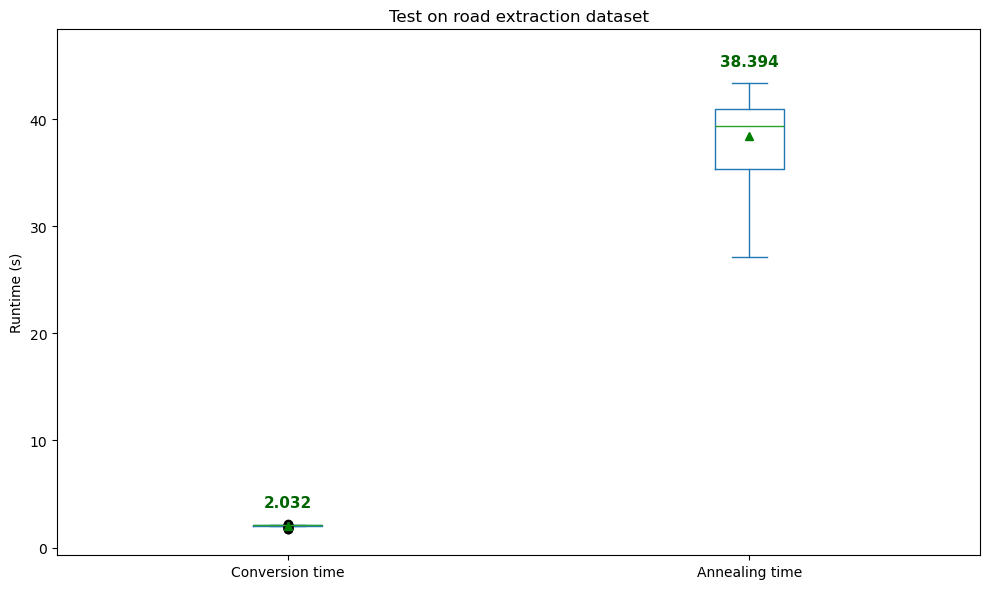

In [8]:
if 'idx' in df.columns:
    df = df.set_index('idx')

df_runtime = df[['Conversion time', 'Annealing time']]

# 1. Generate boxplot with mean markers
ax = df_runtime.plot(
    kind="box",
    figsize=(10, 6),
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "green",
        "markeredgecolor": "green",
    },
)

# Offset to lift text above the top whisker/outliers
y_offset = (df_runtime.values.max() - df_runtime.values.min()) * 0.03

# 2. Iterate through columns and place text above each box
for i, col in enumerate(df_runtime.columns, start=1):
    mean_val = df_runtime[col].mean()
    max_val = df_runtime[col].max()  # Positions above the highest point of the column

    ax.text(
        x=i,
        y=max_val + y_offset,
        s=f"{mean_val:.3f}",
        horizontalalignment="center",
        verticalalignment="bottom",
        fontsize=11,
        color="darkgreen",
        fontweight="bold",
    )

# Adjust y-limit slightly so top text doesn't get clipped by the frame
ax.set_ylim(df_runtime.values.min() - y_offset * 2, df_runtime.values.max() + y_offset * 4)

plt.grid(False)
plt.title("Test on road extraction dataset")
plt.ylabel("Runtime (s)")
plt.tight_layout()
plt.show()

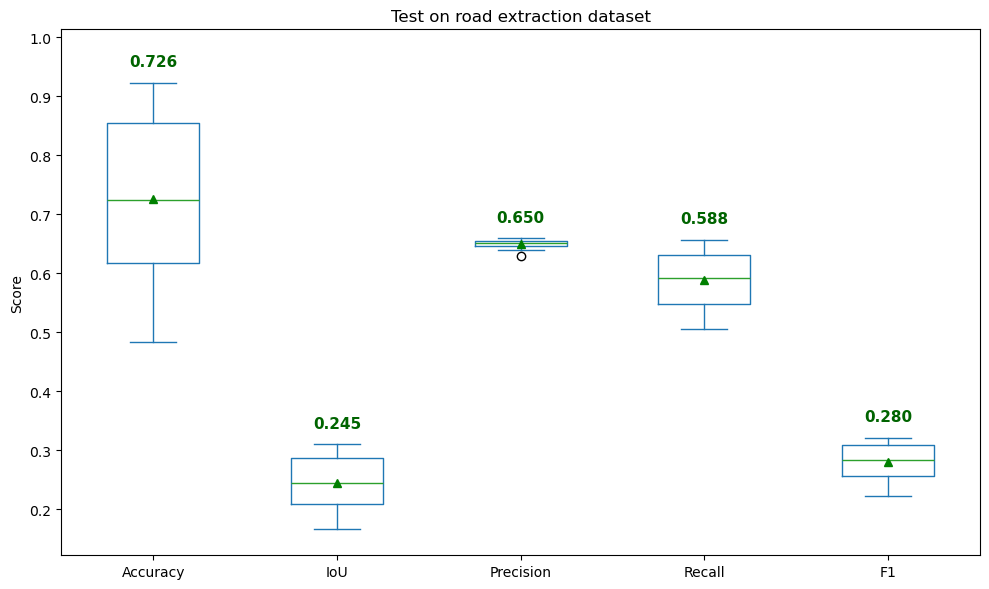

In [9]:
df.drop(columns=['Conversion time', 'Annealing time'], inplace=True)

# 1. Generate boxplot with mean markers
ax = df.plot(
    kind="box",
    figsize=(10, 6),
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "green",
        "markeredgecolor": "green",
    },
)

# Offset to lift text above the top whisker/outliers
y_offset = (df.values.max() - df.values.min()) * 0.03

# 2. Iterate through columns and place text above each box
for i, col in enumerate(df.columns, start=1):
    mean_val = df[col].mean()
    max_val = df[col].max()  # Positions above the highest point of the column

    ax.text(
        x=i,
        y=max_val + y_offset,
        s=f"{mean_val:.3f}",
        horizontalalignment="center",
        verticalalignment="bottom",
        fontsize=11,
        color="darkgreen",
        fontweight="bold",
    )

# Adjust y-limit slightly so top text doesn't get clipped by the frame
ax.set_ylim(df.values.min() - y_offset * 2, df.values.max() + y_offset * 4)

plt.grid(False)
plt.title("Test on road extraction dataset")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

Node sampling + Q-Seg

In [12]:
# test run
i = 0
sample = images[i]
dim = sample.shape[0]

# image to graph
start = time.time()
G = qseg_graph_construction(sample, normalized=False)

bqm, sampleset = annealer_solver_sa(G)
sampleset_first = sampleset.first.sample
end = time.time()
runtime = round(end - start, 3)

accuracy, iou, precision, recall, f1 = qseg_evaluation(sampleset_first, dim, masks[i])
print(runtime, accuracy, iou, f1, precision, recall)

45.306 0.745 0.249 0.285 0.653 0.59


In [7]:
print(len(images), len(masks))

30 0


In [9]:
df_params = pd.read_csv('road_this_work.csv')
l_th = df_params['thresholds'].tolist()
l_k = df_params['k'].tolist()

samplied_results = []

for i in range(len(images)):
    sample = images[i]
    dim = sample.shape[0]

    start = time.time()
    # image to graph
    G = qseg_graph_construction(sample, normalized=False)
    end = time.time()
    conversion_time = round(end-start,3)
    
    start = time.time()
    H, I, important, redundant = importance_sampling(G, threshold=l_th[i], node_size=0.1, show_graph=False)
    sampled_nodes = random_sampling(I, copy.deepcopy(redundant), k=l_k[i], seed=0)
    I.add_nodes_from(sampled_nodes)
    I = update_edgeweights_qseg(I, sample)
    end = time.time()
    sampling_time = round(end-start,3)
    
    start = time.time()
    bqm, sampleset = annealer_solver_sa(I)
    sampleset_first = sampleset.first.sample
    end = time.time()
    annealing_time = round(end-start,3)
    
    start = time.time()
    metrics_df = label_propagation_graph(I, sampleset_first, dim, masks[i])
    end = time.time()
    labeling_time = round(end-start,3)
    
    samplied_results.append({
        'Accuracy': metrics_df['accuracy'].iloc[0],
        'IoU': metrics_df['iou'].iloc[0],
        'Precision': metrics_df['precision'].iloc[0],
        'Recall': metrics_df['recall'].iloc[0],
        'F1': metrics_df['f1'].iloc[0],
        'Conversion time': conversion_time,
        'Sampling time' : sampling_time,
        'Annealing time' : annealing_time,
        'Labeling time' : labeling_time
    })
        
    df_results = pd.DataFrame(samplied_results)
    best_config = df_results.sort_values(by='IoU', ascending=False).iloc[0]

df_sampled = pd.DataFrame(samplied_results)
df_sampled

,Accuracy,IoU,Precision,Recall,F1,Conversion time,Sampling time,Annealing time,Labeling time
0,0.878,0.451,0.500,0.501,0.492,1.834,0.313,1.292,2.862
1,0.706,0.383,0.510,0.533,0.474,1.769,0.307,0.380,2.858
2,0.430,0.230,0.500,0.498,0.336,1.799,0.307,0.160,2.970
3,0.503,0.273,0.501,0.503,0.384,2.002,0.314,0.174,3.028
4,0.764,0.407,0.503,0.509,0.482,1.792,0.328,0.449,3.073
5,0.676,0.353,0.502,0.515,0.435,1.802,0.319,0.407,3.062
6,0.881,0.460,0.507,0.516,0.505,1.797,0.339,1.502,2.854
7,0.750,0.406,0.510,0.527,0.490,1.975,0.321,0.318,2.828
8,0.812,0.415,0.487,0.461,0.465,1.950,0.322,0.835,3.079
9,0.668,0.352,0.505,0.532,0.438,1.795,0.311,0.305,2.855


In [10]:
df_sampled.to_csv('road_qseg_sampled.csv', index=False)

In [14]:
df_sampled = pd.read_csv('road_qseg_sampled.csv', index_col=False)

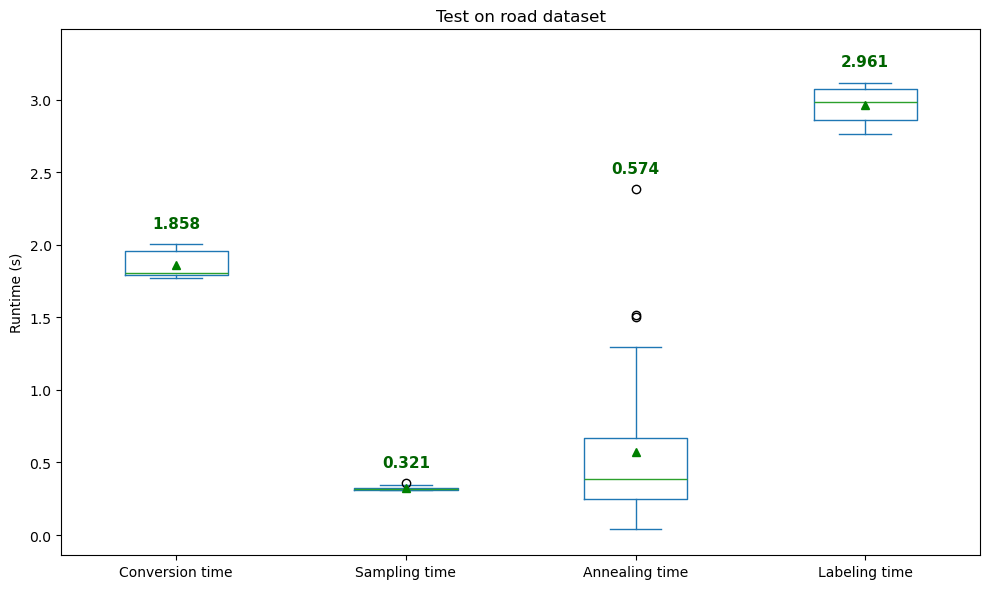

In [15]:
if 'idx' in df_sampled.columns:
    df_runtime = df_sampled.set_index('idx')

df_runtime = df_sampled[['Conversion time', 'Sampling time', 'Annealing time', 'Labeling time']]

# 1. Generate boxplot with mean markers
ax = df_runtime.plot(
    kind="box",
    figsize=(10, 6),
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "green",
        "markeredgecolor": "green",
    },
)

# Offset to lift text above the top whisker/outliers
y_offset = (df_runtime.values.max() - df_runtime.values.min()) * 0.03

# 2. Iterate through columns and place text above each box
for i, col in enumerate(df_runtime.columns, start=1):
    mean_val = df_runtime[col].mean()
    max_val = df_runtime[col].max()  # Positions above the highest point of the column

    ax.text(
        x=i,
        y=max_val + y_offset,
        s=f"{mean_val:.3f}",
        horizontalalignment="center",
        verticalalignment="bottom",
        fontsize=11,
        color="darkgreen",
        fontweight="bold",
    )

# Adjust y-limit slightly so top text doesn't get clipped by the frame
ax.set_ylim(df_runtime.values.min() - y_offset * 2, df_runtime.values.max() + y_offset * 4)

plt.grid(False)
plt.title("Test on road dataset")
plt.ylabel("Runtime (s)")
plt.tight_layout()
plt.show()

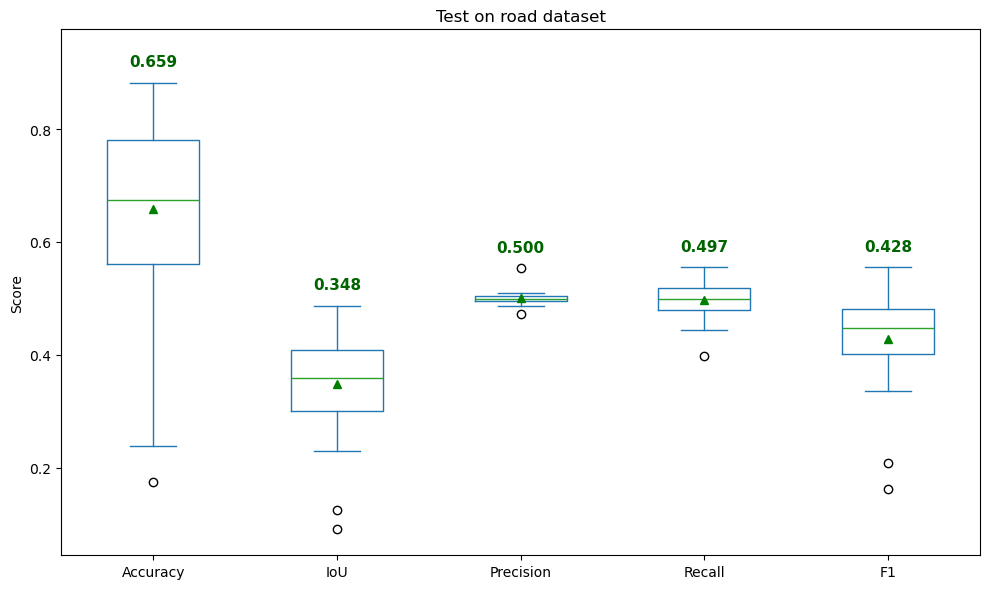

In [16]:
df_sampled.drop(columns=['Conversion time', 'Sampling time', 'Annealing time', 'Labeling time'], inplace=True)

# 1. Generate boxplot with mean markers
ax = df_sampled.plot(
    kind="box",
    figsize=(10, 6),
    showmeans=True,
    meanprops={
        "marker": "^",
        "markerfacecolor": "green",
        "markeredgecolor": "green",
    },
)

# Offset to lift text above the top whisker/outliers
y_offset = (df_sampled.values.max() - df_sampled.values.min()) * 0.03

# 2. Iterate through columns and place text above each box
for i, col in enumerate(df_sampled.columns, start=1):
    mean_val = df_sampled[col].mean()
    max_val = df_sampled[col].max()  # Positions above the highest point of the column

    ax.text(
        x=i,
        y=max_val + y_offset,
        s=f"{mean_val:.3f}",
        horizontalalignment="center",
        verticalalignment="bottom",
        fontsize=11,
        color="darkgreen",
        fontweight="bold",
    )

# Adjust y-limit slightly so top text doesn't get clipped by the frame
ax.set_ylim(df_sampled.values.min() - y_offset * 2, df_sampled.values.max() + y_offset * 4)

plt.grid(False)
plt.title("Test on road dataset")
plt.ylabel("Score")
plt.tight_layout()
plt.show()